In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

def load_results(file_path):
    """
    Load results from a pickle file.

    Args:
        file_path (str): Path to the pickle file.

    Returns:
        dict: Dictionary containing the loaded results.
    """
    try:
        with open(file_path, 'rb') as f:
            results = pickle.load(f)
        return results
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None 

def get_train_metrics(results):
    """
    Extract training metrics from the results dictionary.

    Args:
        results (dict): Dictionary containing training history.

    Returns:
        dict: Dictionary containing lists of training metrics.
    """
    train_metrics = {
        'obj': [],
        'loss': [],
        # 'opt_gap': [],
        'eq_violation_l1': [],
        'ineq_violation_l1': [],
        # 'distance': []    
    }

    for k in range(len(results['train_history'])):
        for key in train_metrics.keys():
            train_metrics[key].append(results['train_history'][k][key])
    
    return train_metrics

# dict_keys(['val_history', 'test_results'])
# dict_keys(['epoch', 'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 
#            'eq_violation_l1_mean', 'eq_violation_l1_max', 
#            'ineq_violation_l1_mean', 'ineq_violation_l1_max'])

def get_val_metrics(results):
    """
    Extract validation metrics from the results dictionary.

    Args:
            results (dict): Dictionary containing validation history.

    Returns:
            dict: Dictionary containing lists of validation metrics.
    """
    val_metrics = {
            'opt_gap_mean': [],
            'opt_gap_std': [],
            'opt_gap_max': [],
            'eq_violation_l1_mean': [],
            'eq_violation_l1_max': [],
            'ineq_violation_l1_mean': [],
            'ineq_violation_l1_max': [],
            'merit_mean': [],
            'merit_max': []
    }

    for k in range(len(results['val_history'])):
        for key in val_metrics.keys():
            val_metrics[key].append(results['val_history'][k][key])
    return val_metrics

In [137]:
from pathlib import Path

base = Path.cwd()

filename = "20260118-172633_MLP_penalty_seed2_nepochs1000_lr0.0001_trainsize7000_finetune_20260116-022657_sup_seedpen_model_940"

path = base / "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" / filename / "results.pkl"

results = load_results(path)

In [138]:
results.keys()  # dict_keys(['train_history', 'val_history', 'test_results'])

dict_keys(['seed', 'method', 'config', 'timestamp', 'training_time_seconds', 'train_history', 'val_history', 'test_results', 'pytorch_version', 'device_used'])

In [139]:
results['test_results']['batch_size_comparison'][256]['metrics']['true_objective']  # 11.688

np.float64(-2.4092202940404004)

In [140]:
28308/620

45.65806451612903

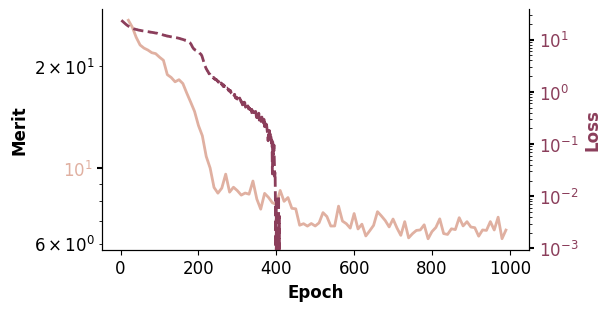

In [141]:
val_metrics = get_val_metrics(results)
train_metrics = get_train_metrics(results)

# Data extraction
x_val = [entry['epoch'] for entry in results['val_history']]
x_train = [entry['epoch'] for entry in results['train_history']]

# Set global font/style for publication
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12})

fig, ax1 = plt.subplots(figsize=(6, 3), constrained_layout=True)

# Data extraction (assumed from previous context)
# x_val, x_train, val_metrics, train_metrics = ...

# Primary Axis (Merit)
color1 = '#e0b0a1'  # Darker, professional blue
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Merit', color='black', fontweight='bold')
ax1.plot(x_val[2:], val_metrics['merit_mean'][2:], color=color1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1, width=1.5)
ax1.spines['top'].set_visible(False)
ax1.set_yscale('log')
# ax1.grid(True, which='major', axis='x', linestyle=':', alpha=0.3)

# Secondary Axis (Loss)
ax2 = ax1.twinx()
color2 = '#8b3e5b'  # Professional burnt orange
ax2.set_ylabel('Loss', color=color2, fontweight='bold')
ax2.plot(x_train[2:], train_metrics['loss'][2:], color=color2, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2, width=1.5)
ax2.spines['top'].set_visible(False)
ax2.set_yscale('log')

# Ensure white background explicitly
fig.patch.set_facecolor('white')

plt.show()

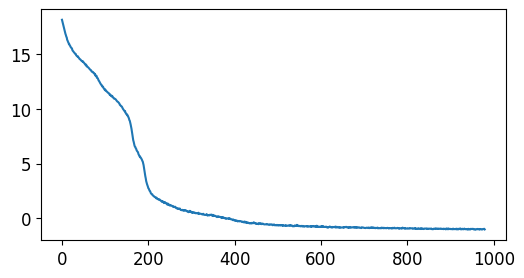

In [142]:
# draw only the merit
plt.figure(figsize=(6, 3))
plt.plot(train_metrics['loss'][20:])
# plt.yscale('log')


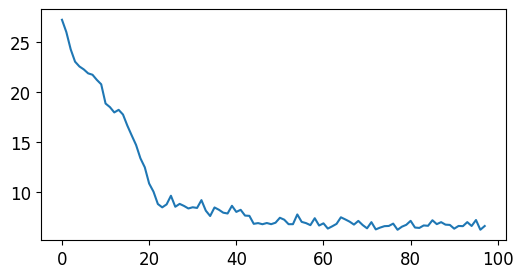

In [143]:
# draw only the merit
plt.figure(figsize=(6, 3))
plt.plot(val_metrics['merit_mean'][2:])
# plt.yscale('log')


In [144]:
# pick the checkpoints right before the merit cannot decrease more than 5% for 10 consecutive times
merit_mean = val_metrics['merit_mean']
best_epoch = 0
best_merit = merit_mean[0]
no_improve_count = 0
for epoch in range(1, len(merit_mean)):
    if merit_mean[epoch] < 0.95 * best_merit:
        best_merit = merit_mean[epoch]
        best_epoch = epoch
        no_improve_count = 0
    else:
        no_improve_count += 1
    if no_improve_count >= 10:
        break
print(f"Best epoch: {results['val_history'][best_epoch]['epoch'] }, Best merit: {best_merit}")
print(f"Last epoch evaluated: {results['val_history'][-1]['epoch']}, {merit_mean[-1]}")

Best epoch: 460, Best merit: 6.7989970218296545
Last epoch evaluated: 990, 6.580093139055258


In [145]:
# find smalles index in merit_mean
min_idx = merit_mean.index(min(merit_mean))
print(results['val_history'][min_idx]['epoch'], merit_mean[min_idx])

790 6.2028885704964605


In [150]:
28308 / 480

58.975

In [147]:
# Get batch comparison data from the loaded results
batch_comparison = results['test_results']['batch_size_comparison']

# Create a more readable DataFrame by expanding the metrics
readable_data = []
for batch_size, data in batch_comparison.items():
    metrics = data['metrics']
    row = {
        'Batch Size': batch_size,
        'Opt Gap Mean': f"{metrics['opt_gap_mean']:.2%}",
        # 'Opt Gap Std': f"{metrics['opt_gap_std']:.4f}",
        # 'Opt Gap Max': f"{metrics['opt_gap_max']:.4f}",
        'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
        # 'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
        'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
        # 'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
        'Average Batch Time (s)': f"{metrics['avg_inference_time']:.4f}", 
    }
    readable_data.append(row)

df_readable = pd.DataFrame(readable_data)
df_readable_styled = df_readable.style.set_properties(**{'text-align': 'center'})
display(df_readable_styled)

,Batch Size,Opt Gap Mean,Eq Violation Mean,Ineq Violation Mean,Average Batch Time (s)
0,256,-803.59%,9.27e-01,2.38e-02,0.0002
1,512,-798.66%,9.27e-01,2.40e-02,0.0002
